In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras import layers
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import sys
import os
import re

import pandas as pd
from sklearn.impute import SimpleImputer

# --- Robust loader for CSV / Excel ---
def load_table(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    ext = os.path.splitext(path)[1].lower()
    if ext == '.csv':
        return pd.read_csv(path)
    if ext in ('.xls', '.xlsx'):
        return pd.read_excel(path, engine='openpyxl')
    raise ValueError(f"Unsupported extension: {ext}")

# Load data (handling potential byte order mark)
demographic_df = load_table('/users/audreysu/AudreyCovidProject/delirium cohort demographics.xlsx')

demographic_df = demographic_df.head(128)

serial_df = load_table('/users/audreysu/AudreyCovidProject/serial_norm_gene_exp_df.csv')

serial_df_2 = load_table('/users/audreysu/AudreyCovidProject/serial_samples_annotation.csv').drop(columns = ["Delirium"])

serial_df = serial_df.rename(columns={serial_df.columns[0]: "gene"})

serial_df.set_index("gene", inplace=True)

serial_df = serial_df.T

serial_df = serial_df.reset_index()

serial_df = serial_df.rename(columns = {serial_df.columns[0] : "X"})

merged_serial = merged_df = pd.merge(
    serial_df,          # left dataframe
    serial_df_2,          # right dataframe (same one in this case)
    on="X")

def transform_value(val):
    match = re.search(r"MVIR1.HS(\d+)", str(val))
    if match:
        code = match.group(1)  # extract the digits after MVIR1HS
        return 1000 + int(code)
    return val

merged_serial["X"] = merged_serial["X"].apply(transform_value)
merged_serial.rename(columns={"X": "Master Record ID"}, inplace=True)

combined_df = pd.merge(demographic_df, merged_serial, on='Master Record ID', how='outer')

combined_df.rename(columns={"Delirium at any time during hospitalization": "Delirium"}, inplace=True)

# combined_df = combined_df.drop(columns=["Sequential Organ Failure Assessment (SOFA) Score"])

combined_df

,Master Record ID,Event Name,Sequential Organ Failure Assessment (SOFA) Score,Age at Admission,Sex at Birth,Race,Hispanic ethnicity,Length of Hospitalization,ICU Length of Stay,SOFA,...,C13orf46,CNTNAP3C,MIR1244-2,EXOC3L2,LINC02009,Subject,Day,Diagnosis,Steroids,Late_del
0,1001,Enrollment (Arm 1: Inpatient Visits),NaN,34.8,Female,White,0,14,12,10,...,9.103527,4.669161,8.513688,5.715513,8.161216,1.0,0.0,1.0,0.0,1.0
1,1001,Enrollment (Arm 1: Inpatient Visits),NaN,34.8,Female,White,0,14,12,10,...,7.003446,5.216636,7.633300,7.816464,8.797642,1.0,4.0,1.0,0.0,1.0
2,1001,Enrollment (Arm 1: Inpatient Visits),NaN,34.8,Female,White,0,14,12,10,...,7.048409,5.333805,7.546325,6.537779,8.088140,1.0,7.0,1.0,0.0,1.0
3,1003,Enrollment (Arm 1: Inpatient Visits),NaN,43.6,Female,Other / Multiple Races,0,26,3,4,...,7.441883,5.194310,8.226801,5.586525,5.913432,3.0,14.0,0.0,0.0,0.0
4,1003,Enrollment (Arm 1: Inpatient Visits),NaN,43.6,Female,Other / Multiple Races,0,26,3,4,...,7.101033,4.820645,8.157196,5.711156,5.570536,3.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,1441,Enrollment (Arm 1: Inpatient Visits),NaN,50.1,Male,Black / African American,0,30,22,NaN,...,5.281029,8.050441,6.627202,9.232871,7.435525,441.0,7.0,0.0,1.0,0.0
317,1450,Enrollment (Arm 1: Inpatient Visits),NaN,49.4,Female,Black / African American,0,18,15,10,...,6.204034,5.179700,7.098033,7.093397,6.265243,450.0,0.0,1.0,1.0,1.0
318,1450,Enrollment (Arm 1: Inpatient Visits),NaN,49.4,Female,Black / African American,0,18,15,10,...,6.047874,5.053804,7.812982,5.647127,5.298750,450.0,14.0,1.0,1.0,1.0
319,1450,Enrollment (Arm 1: Inpatient Visits),NaN,49.4,Female,Black / African American,0,18,15,10,...,5.787628,5.265036,7.688340,5.826759,6.632396,450.0,4.0,1.0,1.0,1.0


In [2]:
combined_df_raw = combined_df.copy()

target = "Delirium"

combined_df = combined_df.dropna(subset=[target]).reset_index(drop=True)
print("Shape after dropping rows with missing target:", combined_df.shape)

# 2️⃣ Identify categorical and numeric columns (exclude target)
cat_cols = combined_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_impute_cols = [c for c in cat_cols if c != target]

num_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
num_impute_cols = [c for c in num_cols if c != target]

print("Categorical columns (will fill mode):", cat_impute_cols)
print("Numeric columns (will impute mean):", num_impute_cols)

# 3️⃣ Fill categorical NaNs with mode (most frequent value)
for c in cat_impute_cols:
    mode_vals = combined_df[c].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if not mode_vals.empty else "Missing"
    combined_df[c] = combined_df[c].fillna(fill_val)

# 4️⃣ Impute numeric NaNs with mean, only if there are rows and columns
if num_impute_cols and len(combined_df) > 0:
    # Filter to only include columns that actually exist in combined_df
    existing_num_cols = [col for col in num_impute_cols if col in combined_df.columns]
    
    if existing_num_cols:
        # Use a safer approach - impute one column at a time
        for col in existing_num_cols:
            combined_df[col] = combined_df[col].fillna(combined_df[col].mean())
        print(f"Imputed {len(existing_num_cols)} numeric columns using fillna")
    else:
        print("No existing numeric columns found for imputation")
else:
    print("Skipping numeric imputation: no numeric columns or no rows.")


# 5️⃣ Optional: double-check no NaNs remain
missing_counts = combined_df.isna().sum()
print("Missing values after imputation:\n", missing_counts[missing_counts > 0])

combined_df = combined_df.drop(columns = ["Conv Plasma Date Started", "Conv Plasma HD ended"])

Shape after dropping rows with missing target: (321, 13144)
Categorical columns (will fill mode): ['Master Record ID', 'Event Name', 'Sequential Organ Failure Assessment (SOFA) Score', 'Age at Admission', 'Sex at Birth', 'Race', 'Hispanic ethnicity', 'Length of Hospitalization', 'ICU Length of Stay', 'SOFA', 'Remdesivir', 'Convalescent plasma', 'IV steroids', 'Dex given', 'Methylpred given', 'Hydrocort given', 'Dementia', 'Deceased', 'Cause of death', 'Was patient on ECMO at any point since the last study visit?', 'Non-invasive ventilation (e.g. BiPAP, CPAP)  ', 'Nasal cannula, face mask, or HFNC oxygen therapy', 'Maximum O2 flow via NC or face mask', 'Invasive ventilation']
Numeric columns (will impute mean): ['WHO Scale', 'Remdesivir Date Started (HD)', 'Remdesiver date ended (HD)', 'Conv Plasma Date Started', 'Conv Plasma HD ended', 'IV steroid HD started', 'IV steroid HD ended', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1', 'NIPAL3', 'LAS1L', 'ENPP4',

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_28951/1742410072.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df[c] = combined_df[c].fillna(fill_val)


Imputed 13119 numeric columns using fillna
Missing values after imputation:
 Conv Plasma Date Started    321
Conv Plasma HD ended        321
dtype: int64


RF best params: {'n_estimators': 200, 'min_samples_split': 8, 'max_depth': 20, 'class_weight': 'balanced'}

RandomForest — AUC: 0.9480
Precision: 0.9473684210526315
Recall: 0.72
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91        40
         1.0       0.95      0.72      0.82        25

    accuracy                           0.88        65
   macro avg       0.90      0.85      0.86        65
weighted avg       0.89      0.88      0.87        65



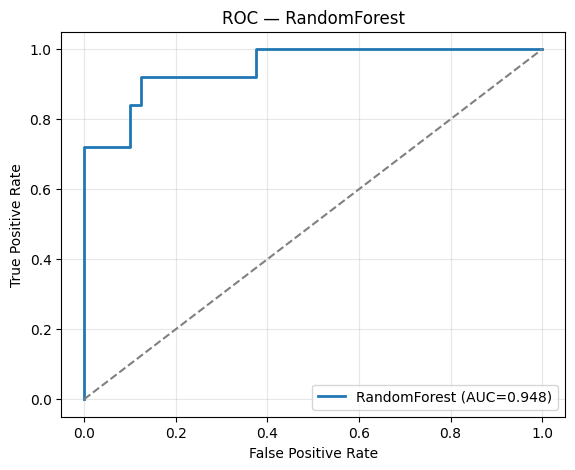

LogReg best params: {'C': 1, 'penalty': 'l1'}

LogisticRegression — AUC: 1.0000
Precision: 1.0
Recall: 0.96
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        40
         1.0       1.00      0.96      0.98        25

    accuracy                           0.98        65
   macro avg       0.99      0.98      0.98        65
weighted avg       0.98      0.98      0.98        65



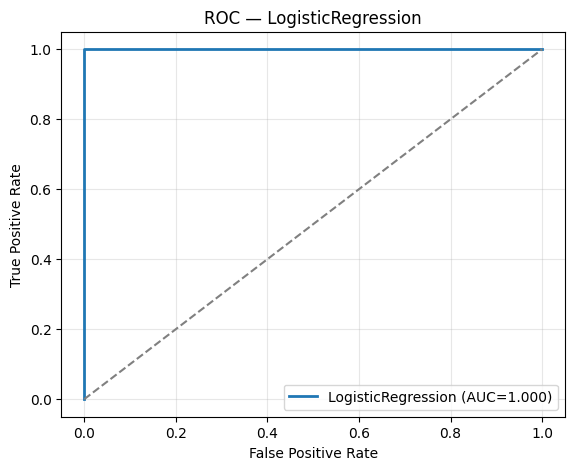

SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

SVM — AUC: 0.9040
Precision: 1.0
Recall: 0.68
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        40
         1.0       1.00      0.68      0.81        25

    accuracy                           0.88        65
   macro avg       0.92      0.84      0.86        65
weighted avg       0.90      0.88      0.87        65



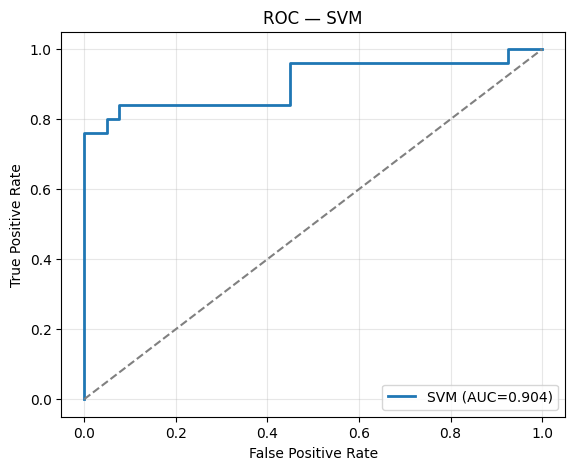

MLP best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (200,), 'alpha': 0.01}

MLP_sklearn — AUC: 0.8300
Precision: 0.9411764705882353
Recall: 0.64
              precision    recall  f1-score   support

         0.0       0.81      0.97      0.89        40
         1.0       0.94      0.64      0.76        25

    accuracy                           0.85        65
   macro avg       0.88      0.81      0.82        65
weighted avg       0.86      0.85      0.84        65



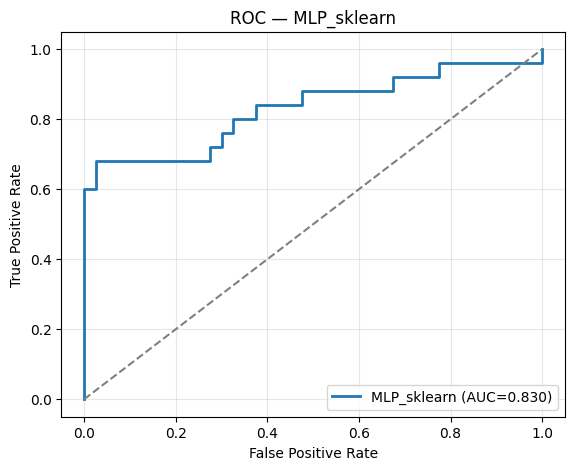

3/3 [==============================] - 0s 3ms/step

RNN_LSTM — AUC: 0.8490
Precision: 0.6666666666666666
Recall: 0.72
              precision    recall  f1-score   support

         0.0       0.82      0.78      0.79        40
         1.0       0.67      0.72      0.69        25

    accuracy                           0.75        65
   macro avg       0.74      0.75      0.74        65
weighted avg       0.76      0.75      0.76        65



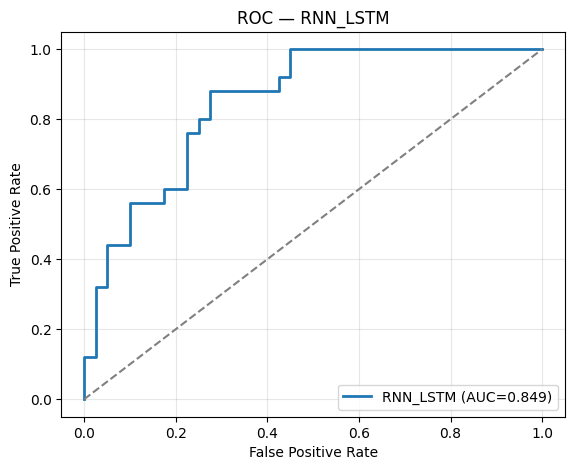

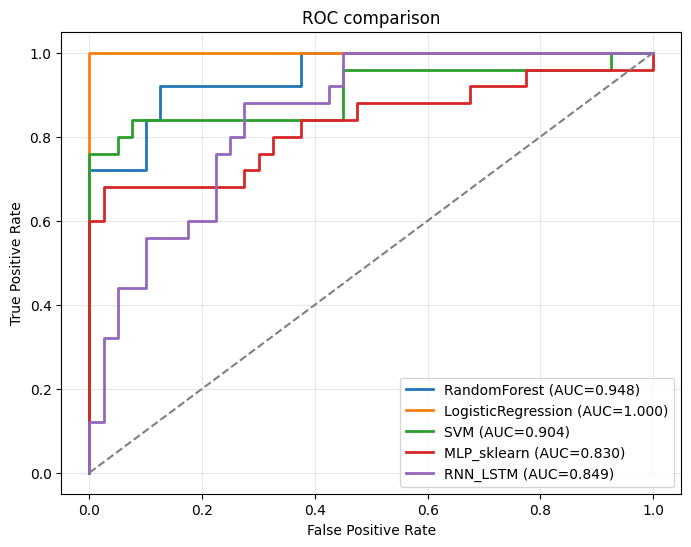


Summary AUCs:
RandomForest: 0.9480
LogisticRegression: 1.0000
SVM: 0.9040
MLP_sklearn: 0.8300
RNN_LSTM: 0.8490


: 

In [ ]:
# ...existing code...
# new cell: train/tune multiple models and plot ROC curves

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from scipy.special import expit

# Optional imblearn
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except Exception:
    has_smote = False

# Use combined_df prepared earlier in this notebook
# link: [`combined_df`](Untitled.ipynb)
df = combined_df.copy()

target = "Delirium"
if target not in df.columns:
    raise RuntimeError(f"Target column '{target}' not found in combined_df")

# prepare X,y: drop non-numeric and obvious id cols
y = df[target].values

X_df = df.drop(columns=[target]).select_dtypes(include=[np.number]).copy()
if X_df.shape[1] == 0:
    raise RuntimeError("No numeric features found in combined_df after dropping target")

X_df = X_df.fillna(X_df.mean())
scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# train/test split stratified
if len(np.unique(y)) < 2:
    raise RuntimeError("Target has single class")
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# helper to evaluate and plot
roc_results = {}
def evaluate_and_plot(name, y_proba):
    if np.unique(y_test).size < 2:
        print(f"Skipping {name}: y_test has single class")
        return
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    y_pred = (y_proba > 0.5).astype(int)
    print(f"\n{name} — AUC: {auc:.4f}")
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print(classification_report(y_test, y_pred, zero_division=0))
    plt.figure(figsize=(6.5,5))
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.title(f"ROC — {name}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.show()
    roc_results[name] = (fpr, tpr, auc)

# Utility: robust proba extractor
def get_proba(model, X):
    try:
        return model.predict_proba(X)[:,1]
    except Exception:
        try:
            d = model.decision_function(X)
            return expit(d)
        except Exception:
            p = model.predict(X)
            if p.ndim == 1:
                return p
            return np.asarray(p).ravel()

# 1) Random Forest (Randomized search)
rf = RandomForestClassifier(random_state=0)
rf_params = {'n_estimators':[100,200,400,800], 'max_depth':[None,10,20,40], 'min_samples_split':[2,4,8], 'class_weight':[None,'balanced']}
rs_rf = RandomizedSearchCV(rf, rf_params, n_iter=12, scoring='roc_auc', cv=skf, random_state=0, n_jobs=-1)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
y_proba_rf = get_proba(best_rf, X_test)
print("RF best params:", rs_rf.best_params_)
evaluate_and_plot("RandomForest", y_proba_rf)

# 2) Logistic Regression (Grid)
lr = LogisticRegression(solver='liblinear', max_iter=2000)
lr_grid = {'C':[0.001,0.01,0.1,1,10], 'penalty':['l2','l1']}
gs_lr = GridSearchCV(lr, lr_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
gs_lr.fit(X_train, y_train)
best_lr = gs_lr.best_estimator_
y_proba_lr = get_proba(best_lr, X_test)
print("LogReg best params:", gs_lr.best_params_)
evaluate_and_plot("LogisticRegression", y_proba_lr)

# 3) SVM (probability) - use smaller grid (can be slow)
svc = SVC(probability=True)
svc_grid = {'C':[0.1,1,5], 'kernel':['linear','rbf'], 'gamma':['scale','auto']}
gs_svc = GridSearchCV(svc, svc_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
gs_svc.fit(X_train, y_train)
best_svc = gs_svc.best_estimator_
y_proba_svc = get_proba(best_svc, X_test)
print("SVM best params:", gs_svc.best_params_)
evaluate_and_plot("SVM", y_proba_svc)

# 4) Sklearn MLP (feedforward NN)
mlp = MLPClassifier(max_iter=3000, random_state=0)
mlp_params = {'hidden_layer_sizes':[(100,), (200,100), (200,)], 'alpha':[1e-4,1e-3,1e-2], 'learning_rate_init':[1e-3,5e-4]}
rs_mlp = RandomizedSearchCV(mlp, mlp_params, n_iter=8, scoring='roc_auc', cv=skf, random_state=0, n_jobs=-1)
rs_mlp.fit(X_train, y_train)
best_mlp = rs_mlp.best_estimator_
y_proba_mlp = get_proba(best_mlp, X_test)
print("MLP best params:", rs_mlp.best_params_)
evaluate_and_plot("MLP_sklearn", y_proba_mlp)

# 5) Keras RNN (LSTM over 1-step sequences) - manual small search
import tensorflow as tf
from tensorflow import keras

n_features = X_train.shape[1]
X_train_rnn = X_train.reshape(-1, 1, n_features).astype(np.float32)
X_test_rnn = X_test.reshape(-1, 1, n_features).astype(np.float32)

def build_lstm(units=64, dropout=0.2, lr=1e-3):
    inp = keras.Input(shape=(1, n_features))
    x = keras.layers.LSTM(units)(inp)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return m

best_val = -1
best_model = None
for units in [32,64]:
    for dropout in [0.2, 0.4]:
        m = build_lstm(units=units, dropout=dropout, lr=1e-3)
        es = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
        # class weights to handle imbalance
        from sklearn.utils.class_weight import compute_class_weight
        classes = np.unique(y_train)
        class_weight = None
        if len(classes)==2:
            cw = compute_class_weight('balanced', classes=classes, y=y_train)
            class_weight = {int(c): w for c,w in zip(classes, cw)}
        hist = m.fit(X_train_rnn, y_train, validation_split=0.15, epochs=80, batch_size=16, verbose=0, callbacks=[es], class_weight=class_weight)
        val_auc = max(hist.history.get('val_auc', [0]))
        if val_auc > best_val:
            best_val = val_auc
            best_model = m

if best_model is None:
    print("RNN training failed")
else:
    y_proba_rnn = best_model.predict(X_test_rnn).ravel()
    evaluate_and_plot("RNN_LSTM", y_proba_rnn)

# Combined ROC plot
plt.figure(figsize=(8,6))
for name,(fpr,tpr,auc) in roc_results.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title("ROC comparison")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()

# Print summary AUCs
print("\nSummary AUCs:")
for name,(fpr,tpr,auc) in roc_results.items():
    print(f"{name}: {auc:.4f}")

# ...existing code...

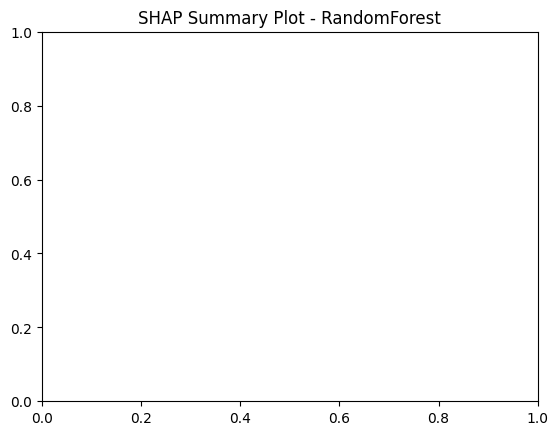

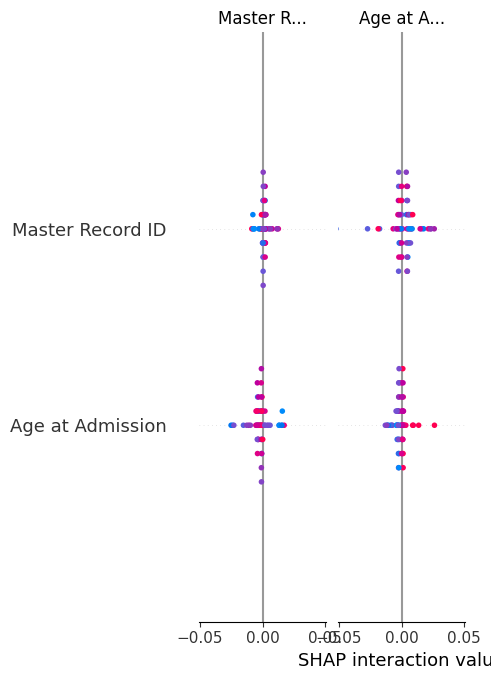

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# New section: SHAP summary plots for each trained model
import shap

# Prepare feature names and data for SHAP
feature_names = X_df.columns.tolist()

# For TreeExplainer (RandomForest), drop any extra columns if present (should be none here)
X_for_shap = X_test.copy()

# 1) SHAP for RandomForest using TreeExplainer
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_for_shap)
plt.title("SHAP Summary Plot - RandomForest")
shap.summary_plot(shap_values_rf, X_for_shap, feature_names=feature_names, show=True)

# 2) SHAP for Logistic Regression using KernelExplainer
# KernelExplainer needs a background dataset (use a subset of training data)
background_lr = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]
explainer_lr = shap.KernelExplainer(best_lr.predict_proba, background_lr)
shap_values_lr = explainer_lr.shap_values(X_for_shap[:50])  # limit to 50 samples for speed
plt.title("SHAP Summary Plot - LogisticRegression")
shap.summary_plot(shap_values_lr, X_for_shap[:50], feature_names=feature_names, show=True)

# 3) SHAP for SVM using KernelExplainer
background_svc = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]
explainer_svc = shap.KernelExplainer(best_svc.predict_proba, background_svc)
shap_values_svc = explainer_svc.shap_values(X_for_shap[:50])
plt.title("SHAP Summary Plot - SVM")
shap.summary_plot(shap_values_svc, X_for_shap[:50], feature_names=feature_names, show=True)

# 4) SHAP for MLP (sklearn) using KernelExplainer
background_mlp = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]
explainer_mlp = shap.KernelExplainer(best_mlp.predict_proba, background_mlp)
shap_values_mlp = explainer_mlp.shap_values(X_for_shap[:50])
plt.title("SHAP Summary Plot - MLP_sklearn")
shap.summary_plot(shap_values_mlp, X_for_shap[:50], feature_names=feature_names, show=True)

# 5) SHAP for Keras RNN (LSTM) using DeepExplainer
# Prepare input shape for explainer: (samples, timesteps=1, features)
X_test_rnn_small = X_test_rnn[:50]
explainer_rnn = shap.DeepExplainer(best_model, X_train_rnn[np.random.choice(X_train_rnn.shape[0], min(100, X_train_rnn.shape[0]), replace=False)])
shap_values_rnn = explainer_rnn.shap_values(X_test_rnn_small)
# shap_values_rnn is a list with one array of shape (samples, timesteps, features)
# Collapse timesteps dimension (only 1 timestep here)
shap_values_rnn_2d = shap_values_rnn[0].reshape(shap_values_rnn[0].shape[0], shap_values_rnn[0].shape[2])
plt.title("SHAP Summary Plot - RNN_LSTM")
shap.summary_plot(shap_values_rnn_2d, X_test_rnn_small.reshape(X_test_rnn_small.shape[0], n_features), feature_names=feature_names, show=True)
